# Import libaries

In [30]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import copy

from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

# 0. Load data

In [3]:
path = kagglehub.dataset_download(
    "jainilcoder/netflix-stock-price-prediction",
    output_dir="data"
)

DATASET_DIR = Path("data")
DATA_DIR = DATASET_DIR / "NFLX.csv"

print("Path to dataset files:", DATA_DIR)

Path to dataset files: data\NFLX.csv


# 1. Data inspection

In [4]:
df = pd.read_csv(DATA_DIR)

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head(1)

Shape: (1009, 7)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.0,267.899994,250.029999,254.259995,254.259995,11896100


### Info
The dataset contains **1,009** records of Netflix stock data, including `Open`, `Close`, `High`, `Low`, `Volume`, and `Date` features. The dataset is relatively small, but it is suitable for this project because it is my first Time Series project. It provides a good opportunity to learn how LSTM and GRU models work with sequential data.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1009 non-null   str    
 1   Open       1009 non-null   float64
 2   High       1009 non-null   float64
 3   Low        1009 non-null   float64
 4   Close      1009 non-null   float64
 5   Adj Close  1009 non-null   float64
 6   Volume     1009 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 55.3 KB


### Info
There are no missing values in the dataset. It contains 6 numerical features and 1 string feature, which is the `Date` column.

In [6]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1.009000e+03
mean,419.059673,425.320703,412.374044,419.000733,419.000733,7.570685e+06
std,108.537532,109.262960,107.555867,108.289999,108.289999,5.465535e+06
min,233.919998,250.649994,231.229996,233.880005,233.880005,1.144000e+06
25%,331.489990,336.299988,326.000000,331.619995,331.619995,4.091900e+06
50%,377.769989,383.010010,370.880005,378.670013,378.670013,5.934500e+06
75%,509.130005,515.630005,502.529999,509.079987,509.079987,9.322400e+06
max,692.349976,700.989990,686.090027,691.690002,691.690002,5.890430e+07


### Info
The features have a wide range of values, which is expected because Netflix's stock price has experienced many ups and downs over the years. The data will need to be scaled before training the model to make the training process more stable and efficient.

# 2. Evaluate data analysis

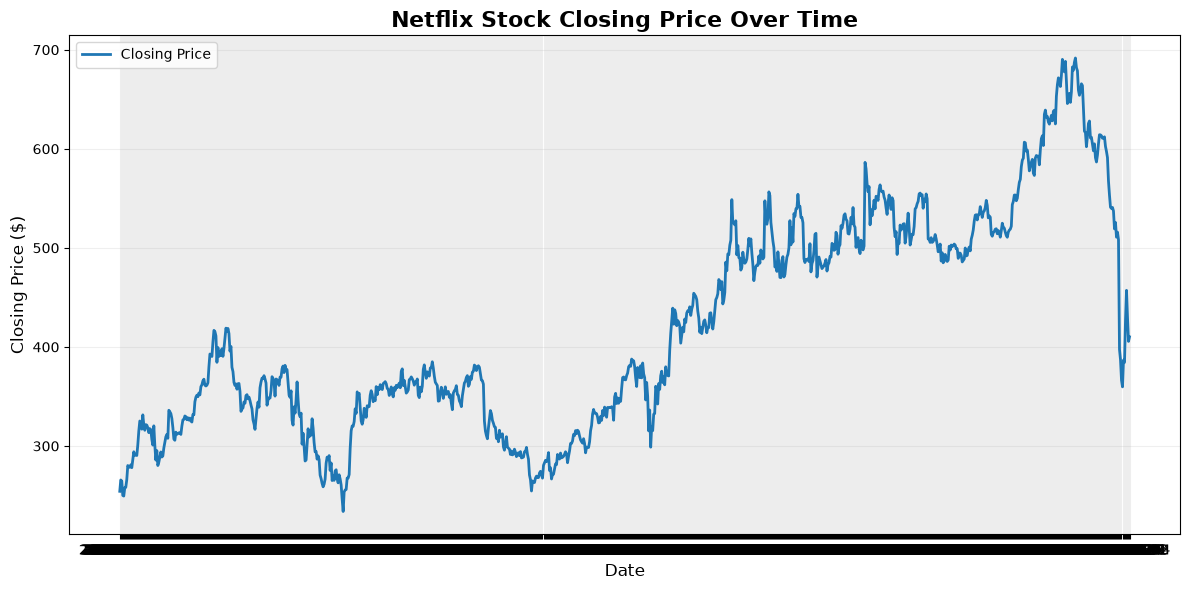

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["Date"],
    df["Close"],
    linewidth=2,
    label="Closing Price"
)

plt.title(
    "Netflix Stock Closing Price Over Time",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date", fontsize=12)
plt.ylabel("Closing Price ($)", fontsize=12)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Observation
In the first year (2018), the stock price fluctuated between around **$220** and **$420**. After that, the price showed a clear increasing trend, with a major breakout around the end of 2021, when the price dropped from around **$700** to **$350**.

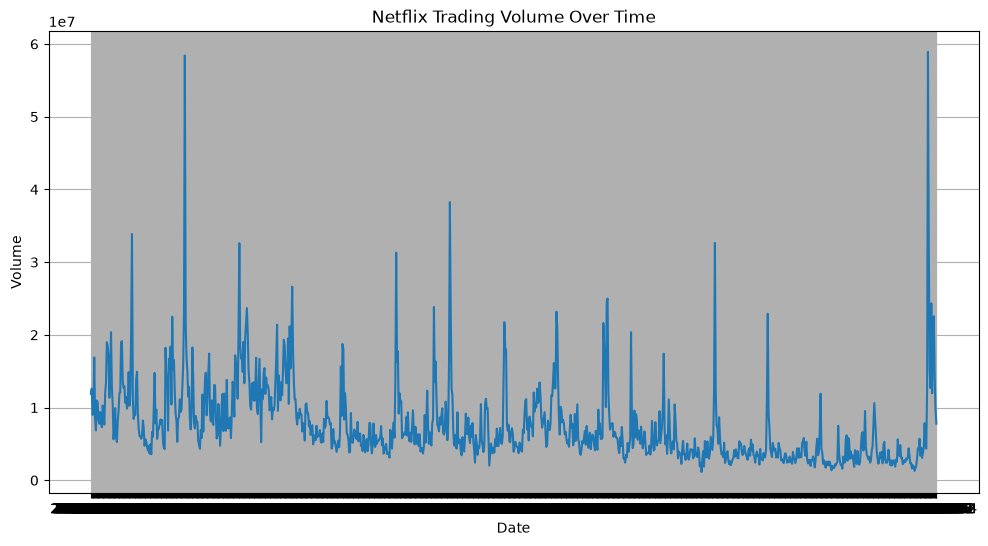

In [8]:
plt.figure(figsize=(12, 6))

plt.plot(df["Date"], df["Volume"])

plt.title("Netflix Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid()
plt.show()

### Observation
If we compare the volume with the price movement, we can see that high trading volumes were often associated with significant price movements, either upward or downward. However, there are also some periods where high trading volume did not result in a noticeable change in the stock price.

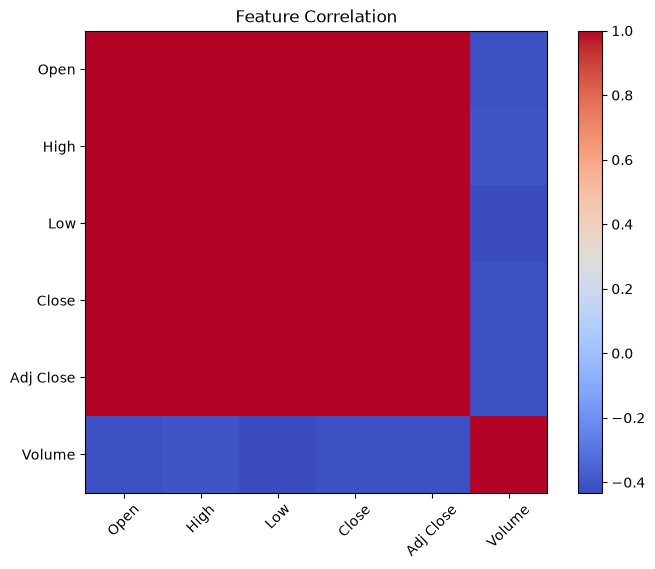

In [9]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(8, 6))

plt.imshow(corr, cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Feature Correlation")
plt.show()

### Observation
The correlation matrix shows a very strong positive correlation between `Open`, `High`, `Low`, and `Close` prices. This is expected because these features describe different aspects of the stock price during the same trading day. In contrast, `Volume` has a much weaker correlation with the price-related features, suggesting that trading volume does not move directly with the stock price.

# 3. Train, validation and test split

## Split the data

In [10]:
features, target = ["Open", "High", "Low", "Close", "Volume"], "Close"
TRAIN_SIZE, VAL_SIZE = 0.8, 0.1

train_size = int(len(df) * TRAIN_SIZE)
val_size = int(len(df) * VAL_SIZE)

train = df.iloc[:train_size]
val = df.iloc[train_size:train_size + val_size]
test = df.iloc[train_size + val_size:]

print("Train:", train["Date"].min(), "→", train["Date"].max())
print("Validation:", val["Date"].min(), "→", val["Date"].max())
print("Test:", test["Date"].min(), "→", test["Date"].max())

Train: 2018-02-05 → 2021-04-20
Validation: 2021-04-21 → 2021-09-10
Test: 2021-09-13 → 2022-02-04


## Scal the data

In [11]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train[features])
val_scaled = scaler.transform(val[features])
test_scaled = scaler.transform(test[features])

train_scaled[0]

array([0.08056696, 0.05034439, 0.05542943, 0.05782213, 0.18775582])

# 4. Prepare the data for LSTM model

## Create sequences

In [12]:
lookback = 60

def create_sequences(data, lookback):
    X = []
    y = []

    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i, 3])

    return np.array(X), np.array(y)

val_input = np.concatenate([
    train_scaled[-lookback:],
    val_scaled
])

test_input = np.concatenate([
    val_scaled[-lookback:],
    test_scaled
])

X_train, y_train = create_sequences(train_scaled, lookback)

X_val, y_val = create_sequences(val_input, lookback)

X_test, y_test = create_sequences(test_input, lookback)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (747, 60, 5)
y_train: (747,)
X_val: (100, 60, 5)
y_val: (100,)
X_test: (102, 60, 5)
y_test: (102,)


## Create tensors

In [13]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print(X_train.shape)
print(y_train.shape)

torch.Size([747, 60, 5])
torch.Size([747])


## Create data loaders

In [20]:
BATCH_SIZE = 32

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

X_batch, y_batch = next(iter(train_loader))

# Samples - Days - Features (Open, High, Low, Close, Volume)
print("X batch:", X_batch.shape)
print("y batch:", y_batch.shape)

X batch: torch.Size([32, 60, 5])
y batch: torch.Size([32])


# 5. Create LSTM

In [27]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)

        out = out[:, -1, :]

        out = self.fc(out)

        return out

INPUT_SIZE = 5
HIDDEN_SIZE = 64
NUM_LAYERS = 1

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = LSTM(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS
).to(device)

print(model)

LSTM(
  (lstm): LSTM(5, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


# 6. Training loop

In [34]:
EPOCHS = 100
PATIENCE = 10

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=0.001
)

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    # =====================
    # Train
    # =====================

    model.train()

    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(
            predictions.squeeze(),
            y_batch
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)


    # =====================
    # Validation
    # =====================

    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)

            loss = criterion(
                predictions.squeeze(),
                y_batch
            )

            val_loss += loss.item()

    val_loss /= len(val_loader)


    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.6f} "
        f"Val Loss: {val_loss:.6f}"
    )


    # =====================
    # Early stopping
    # =====================

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        best_model_state = copy.deepcopy(model.state_dict())

    else:

        patience_counter += 1

        if patience_counter >= PATIENCE:

            print("Early stopping triggered.")

            break

model.load_state_dict(best_model_state)

Epoch [1/100] Train Loss: 0.001434 Val Loss: 0.001833
Epoch [2/100] Train Loss: 0.001719 Val Loss: 0.002084
Epoch [3/100] Train Loss: 0.001398 Val Loss: 0.000959
Epoch [4/100] Train Loss: 0.001001 Val Loss: 0.001163
Epoch [5/100] Train Loss: 0.001043 Val Loss: 0.001236
Epoch [6/100] Train Loss: 0.001181 Val Loss: 0.001331
Epoch [7/100] Train Loss: 0.001421 Val Loss: 0.001747
Epoch [8/100] Train Loss: 0.001668 Val Loss: 0.002536
Epoch [9/100] Train Loss: 0.001766 Val Loss: 0.002859
Epoch [10/100] Train Loss: 0.001534 Val Loss: 0.002265
Epoch [11/100] Train Loss: 0.001129 Val Loss: 0.001228
Epoch [12/100] Train Loss: 0.000947 Val Loss: 0.000868
Epoch [13/100] Train Loss: 0.000905 Val Loss: 0.000776
Epoch [14/100] Train Loss: 0.000898 Val Loss: 0.000763
Epoch [15/100] Train Loss: 0.000900 Val Loss: 0.000768
Epoch [16/100] Train Loss: 0.000904 Val Loss: 0.000780
Epoch [17/100] Train Loss: 0.000911 Val Loss: 0.000798
Epoch [18/100] Train Loss: 0.000921 Val Loss: 0.000824
Epoch [19/100] Trai

<All keys matched successfully>

# 7. Visualize results

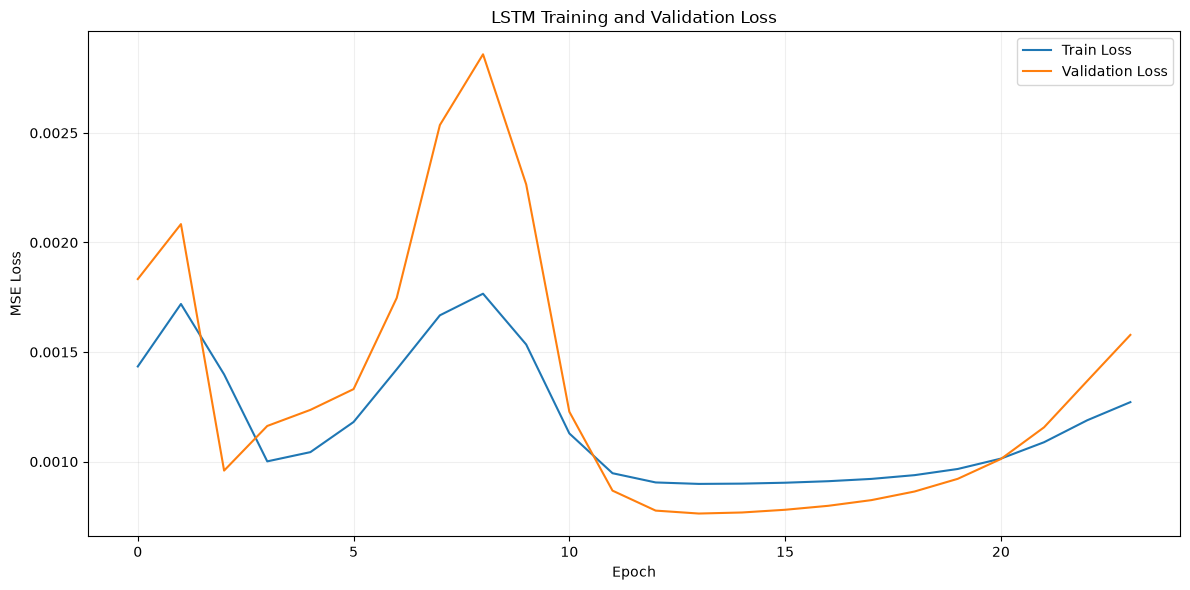

In [35]:
plt.figure(figsize=(12, 6))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Observation
The model does not show a smooth decrease in training and validation loss. After some fluctuations between epochs 1 and 8, the losses become more stable. The model achieves low training and validation loss around epoch 13, after which both values start to increase. Early stopping is triggered after the validation loss stops improving.

# 8. Test results

## Test loop

In [37]:
model.eval()

predictions = []
actuals = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        output = model(X_batch)

        predictions.extend(
            output.view(-1).cpu().numpy()
        )

        actuals.extend(
            y_batch.numpy()
        )

predictions = np.array(predictions)
actuals = np.array(actuals)

print("Predictions shape:", predictions.shape)
print("Actuals shape:", actuals.shape)

Predictions shape: (102,)
Actuals shape: (102,)


## Inverse scaling

In [39]:
close_min = scaler.data_min_[3]
close_max = scaler.data_max_[3]

predictions_real = (
    predictions * (close_max - close_min) + close_min
)

actuals_real = (
    actuals * (close_max - close_min) + close_min
)

for i in range(10):
    print(
        f"Actual: ${actuals_real[i]:.2f} | "
        f"Predicted: ${predictions_real[i]:.2f}"
    )

Actual: $589.29 | Predicted: $593.24
Actual: $577.76 | Predicted: $584.22
Actual: $582.87 | Predicted: $575.82
Actual: $586.50 | Predicted: $577.45
Actual: $589.35 | Predicted: $580.30
Actual: $575.43 | Predicted: $583.62
Actual: $573.14 | Predicted: $574.19
Actual: $590.65 | Predicted: $572.14
Actual: $593.26 | Predicted: $585.57
Actual: $592.39 | Predicted: $587.92


## Visualize the results

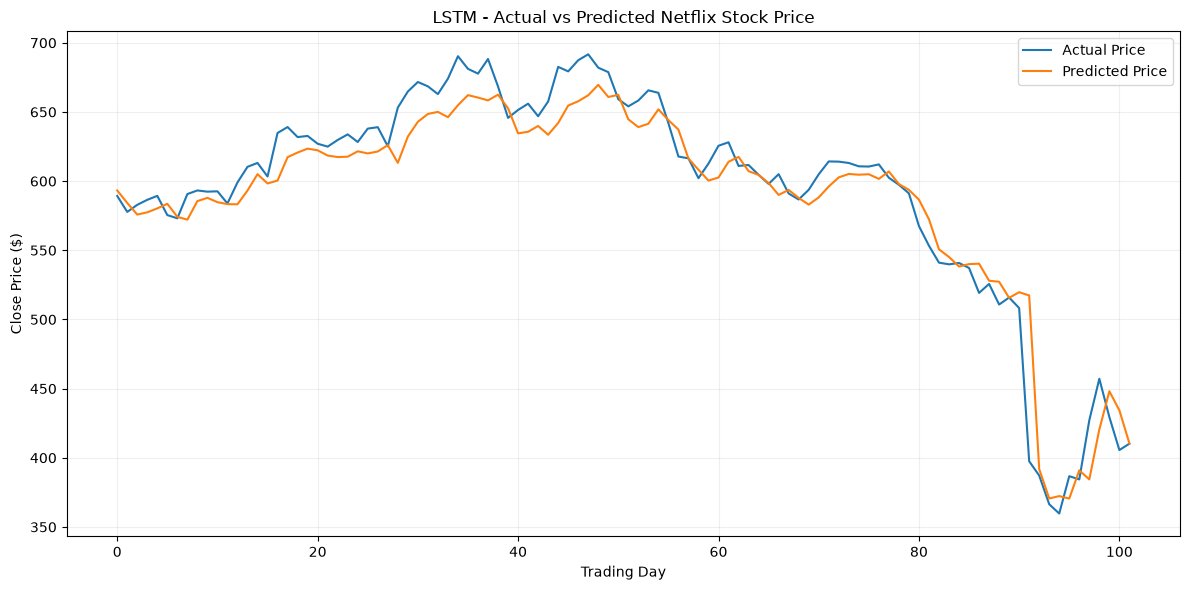

In [40]:
plt.figure(figsize=(12, 6))

plt.plot(actuals_real, label="Actual Price")
plt.plot(predictions_real, label="Predicted Price")

plt.title("LSTM - Actual vs Predicted Netflix Stock Price")
plt.xlabel("Trading Day")
plt.ylabel("Close Price ($)")

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Observation
The model's predictions are quite close to the actual results, especially in the second half of the chart. However, the predictions are not perfect and there is still room for improvement. The model will need further training and tuning to achieve better results, which will be one of my goals later in other project.